In [5]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
df = pd.read_csv('clean_comments.csv').dropna(subset=['clean_comment'])
df.shape

(54153, 3)

In [13]:
def balancing_the_imbalance(imbalance_method=None, weights=False):
  ngram_range = (1, 3)
  max_features = 400
  X_train, X_test, y_train, y_test = train_test_split(df['clean_comment'], df['category'], test_size=0.2, random_state=42, stratify=df['category'])

  vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=max_features)
  X_train_vec = vectorizer.fit_transform(X_train)  # Fit on training data
  X_test_vec = vectorizer.transform(X_test)

  if weights:
    class_weight = 'balanced'
  else:
    class_weight = None


  if imbalance_method == 'oversampling':
      smote = SMOTE(random_state=42)
      X_train_vec, y_train = smote.fit_resample(X_train_vec, y_train)
  elif imbalance_method == 'adasyn':
      adasyn = ADASYN(random_state=42)
      X_train_vec, y_train = adasyn.fit_resample(X_train_vec, y_train)
  elif imbalance_method == 'undersampling':
      rus = RandomUnderSampler(random_state=42)
      X_train_vec, y_train = rus.fit_resample(X_train_vec, y_train)
  elif imbalance_method == 'smote_enn':
      smote_enn = SMOTEENN(random_state=42)
      X_train_vec, y_train = smote_enn.fit_resample(X_train_vec, y_train)


  n_estimators = 200
  max_depth = 15

  model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, class_weight=class_weight)
  model.fit(X_train_vec, y_train)

  y_pred = model.predict(X_test_vec)
  accuracy = accuracy_score(y_test, y_pred)
  print(accuracy)
  classification_rep = classification_report(y_test, y_pred)
  print(classification_rep)

  conf_matrix = confusion_matrix(y_test, y_pred)
  plt.figure(figsize=(8, 6))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title(f"Confusion Matrix: BoW Trigrams, Imbalance={imbalance_method}")
  plt.show()

0.6366909795956052
              precision    recall  f1-score   support

           0       0.45      0.54      0.49      2109
           1       0.59      0.78      0.67      3379
           2       0.82      0.58      0.68      5343

    accuracy                           0.64     10831
   macro avg       0.62      0.63      0.61     10831
weighted avg       0.68      0.64      0.64     10831



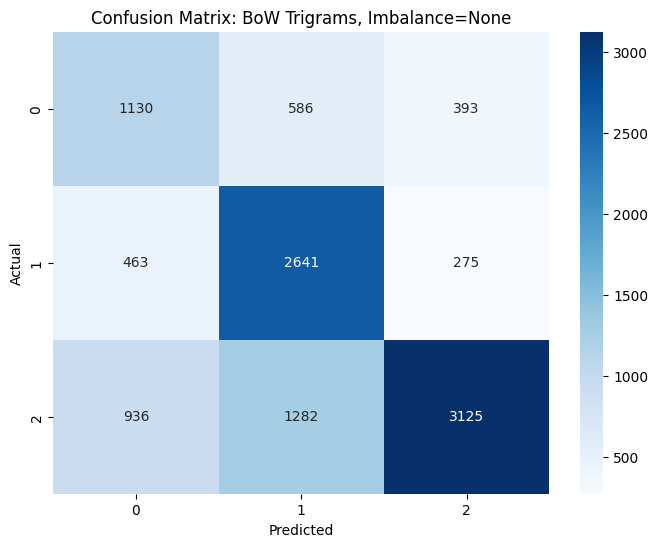

In [14]:
imbalance_methods = ['oversampling', 'adasyn', 'undersampling', 'smote_enn']

balancing_the_imbalance(weights=True)


0.642138306712215
              precision    recall  f1-score   support

           0       0.40      0.46      0.43      2109
           1       0.62      0.69      0.65      3379
           2       0.79      0.68      0.73      5343

    accuracy                           0.64     10831
   macro avg       0.60      0.61      0.60     10831
weighted avg       0.66      0.64      0.65     10831



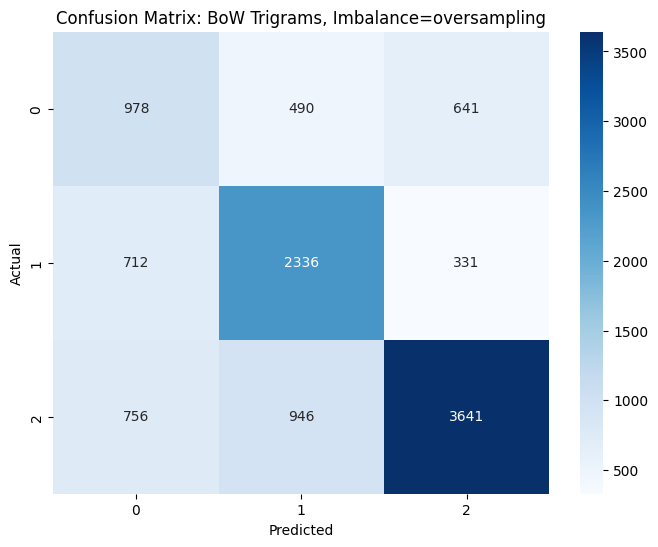

0.6192410673068045
              precision    recall  f1-score   support

           0       0.34      0.54      0.42      2109
           1       0.65      0.56      0.60      3379
           2       0.80      0.69      0.74      5343

    accuracy                           0.62     10831
   macro avg       0.60      0.60      0.59     10831
weighted avg       0.66      0.62      0.63     10831



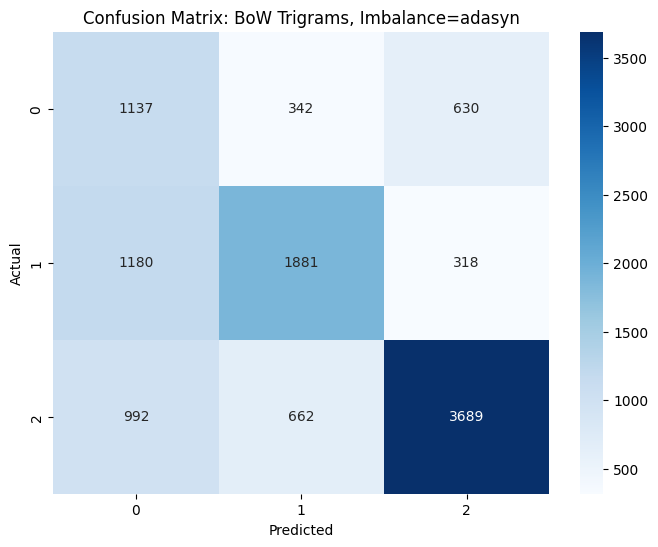

0.6255193426276429
              precision    recall  f1-score   support

           0       0.43      0.59      0.50      2109
           1       0.59      0.78      0.67      3379
           2       0.85      0.54      0.66      5343

    accuracy                           0.63     10831
   macro avg       0.62      0.64      0.61     10831
weighted avg       0.69      0.63      0.63     10831



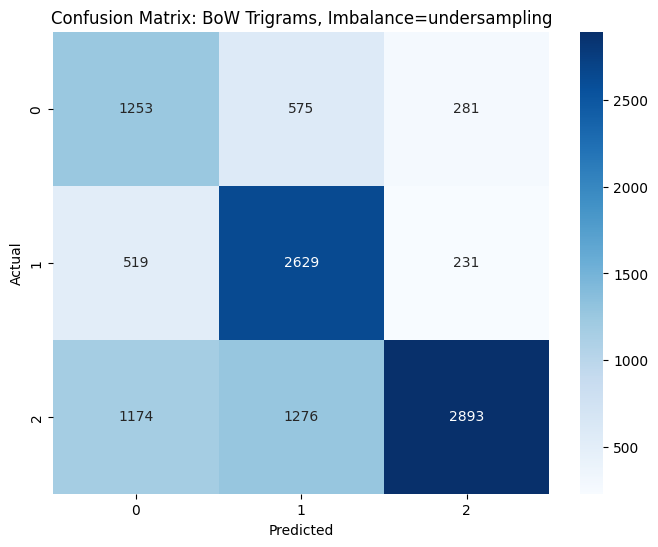

0.44889668543994093
              precision    recall  f1-score   support

           0       0.28      0.74      0.41      2109
           1       0.54      0.71      0.61      3379
           2       0.95      0.17      0.29      5343

    accuracy                           0.45     10831
   macro avg       0.59      0.54      0.44     10831
weighted avg       0.70      0.45      0.42     10831



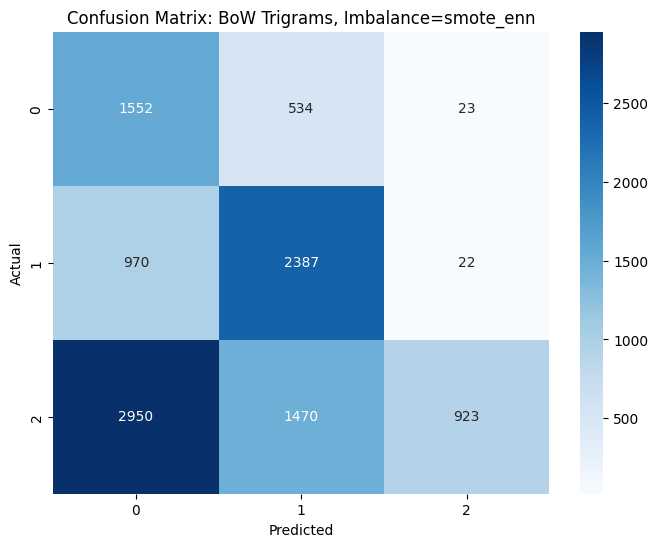

In [15]:
for method in imbalance_methods:
    balancing_the_imbalance(method)

UnderSampling worked the best with this Code, we increase our macroavg from .50 to .60, while decreasing accuracy by <1%